In [ ]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator, RectBivariateSpline

C_ells_data = np.load("C_ells_shells_T_AGN.npz")
n_shells = len(C_ells_data['shell_boundaries_z']) - 1
C_ells = C_ells_data['C_ells']
ell = C_ells_data['ell']
sigma8_fid = C_ells_data['sigma_8_fid']
T_AGN_inter = C_ells_data['T_AGN']
T_AGN_inter = np.linspace(6.8,8.8, 15)
zb = C_ells_data['shell_boundaries_z']

In [2]:
def get_c_ells(T_AGN =7.8, sigma8 = .8, lmax = 10000):
    ell_eval = np.arange(lmax)
    c_ells_return = np.zeros((n_shells,n_shells,len(ell_eval)))
    for i_shell in range(n_shells):
        for j_shell in range(i_shell,n_shells):
            C_ells_inter = RectBivariateSpline(T_AGN_inter, ell, sigma8**2/sigma8_fid**2*C_ells[:,i_shell, j_shell,:])
            c_ells_return[i_shell,j_shell,:] = C_ells_inter(T_AGN,ell_eval)
            c_ells_return[j_shell,i_shell,:] = c_ells_return[i_shell,j_shell,:]
    return ell_eval,c_ells_return
                
    

In [3]:
ells, test_cell = get_c_ells(T_AGN=6.8, sigma8=1)


0 0
0 1
1 1
1 2
2 2
2 3
3 3
3 4
4 4
4 5
5 5
5 6
6 6
6 7
7 7
7 8
8 8
8 9
9 9
9 10
10 10
10 11
11 11
11 12
12 12
12 13
13 13
13 14
14 14
14 15
15 15
15 16
16 16
16 17
17 17
17 18
18 18
18 19
19 19


(1e-08, 0.1)

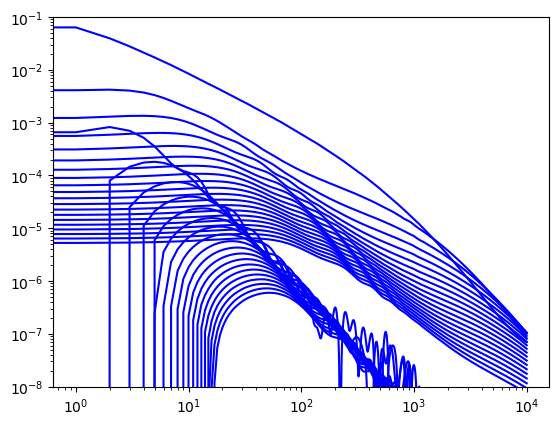

In [ ]:
import matplotlib.pyplot as plt

for i_shell in range(n_shells):
    for j_shell in range(i_shell,n_shells):
        if np.abs(i_shell - j_shell) < 2:
            plt.loglog(ells, test_cell[i_shell,j_shell,:], color = "blue")

plt.ylim(1e-8,1e-1)

In [5]:
import glass

# apply discretisation to the full set of spectra:
# - HEALPix pixel window function (`nside=nside`)
# - maximum angular mode number (`lmax=lmax`)
# - number of correlated shells (`ncorr=3`)
shells = glass.tophat_windows(zb)

nbins = len(shells)
nside = 256
lmax = nside
cls_new = [test_cell[j, i] for i, j in glass.spectra_indices(nbins)] # These are in glass ordering



cls_binned = glass.discretized_cls(cls_new, nside=nside, lmax=ell[-1])


# set up lognormal fields for simulation
fields = glass.lognormal_fields(shells)

# compute Gaussian spectra for lognormal fields from discretised spectra
gls = glass.solve_gaussian_spectra(fields, cls_binned)

# this generator will yield the matter fields in each shell
matter = glass.generate(fields, gls, nside)

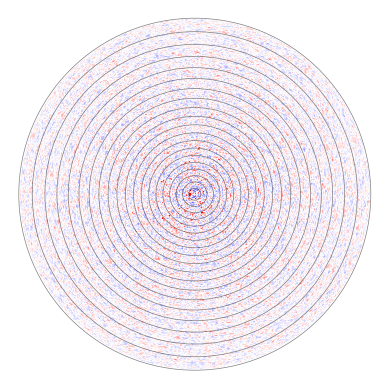

In [6]:
import healpy as hp

# make a 2d grid in redshift
n = 2000
zend = 1.05 * zb[-1]
x, y = np.mgrid[-zend : zend : 1j * n, -zend : zend : 1j * n]
z = np.hypot(x, y)
grid = np.full(z.shape, np.nan)

# set up the plot
ax = plt.subplot(111)
ax.axis("off")

# simulate and project an annulus of each matter shell onto the grid
for i, delta_i in enumerate(matter):
    zmin, zmax = zb[i], zb[i + 1]
    g = (zmin <= z) & (z < zmax)
    zg = np.sqrt(1 - (z[g] / zmax) ** 2)
    theta, phi = hp.vec2ang(np.transpose([x[g] / zmax, y[g] / zmax, zg]))

    grid[g] = hp.get_interp_val(delta_i, theta, phi)
    ax.add_patch(
        plt.Circle((0, 0), zmax / zend, fc="none", ec="k", lw=0.5, alpha=0.5, zorder=1),
    )

# show the grid of shells
ax.imshow(grid, extent=[-1, 1, -1, 1], zorder=0, cmap="bwr", vmin=-1, vmax=1)

# show the resulting plot
plt.show()